In [6]:
import numpy as np 
import pandas as pd 

# log scaling 

x = pd.Series([10,20,30,40,50])
x_log = np.log1p(x)
x_sqrt = np.sqrt(x)
print(x_log)
print(x_sqrt)

0    2.397895
1    3.044522
2    3.433987
3    3.713572
4    3.931826
dtype: float64
0    3.162278
1    4.472136
2    5.477226
3    6.324555
4    7.071068
dtype: float64


In [8]:
# min max scaling 
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

data = np.array([[100],[200],[300],[400],[500],[600]])
scaled_data = scaler.fit_transform(data)
print("Original data: ",data)
print(f"Scaled data: {scaled_data}")

Original data:  [[100]
 [200]
 [300]
 [400]
 [500]
 [600]]
Scaled data: [[0. ]
 [0.2]
 [0.4]
 [0.6]
 [0.8]
 [1. ]]


In [11]:
#   normalization by decimal scaling 

data = np.array([100,200,300,400,500,34,231,132,232])

max_val = np.max(np.abs(data))
j = len(str(max_val))
print(max_val)
print(j)
scaled_data = data/(10**j)
print(f"Original data: ",data)
print(f"Scaled data: {scaled_data}")

500
3
Original data:  [100 200 300 400 500  34 231 132 232]
Scaled data: [0.1   0.2   0.3   0.4   0.5   0.034 0.231 0.132 0.232]


In [13]:
from sklearn.preprocessing import LabelEncoder 
le = LabelEncoder()

city = ['pokhara','kathmandu','biratnagar','sunsari']

labeled_city  = le.fit_transform(city)
print(labeled_city)

[2 1 0 3]


In [15]:
import pandas as pd 

df = pd.DataFrame({
    'City':['Pokhara',"Kathmandu",'Sunsari','Itahari']
})

df_encoded = pd.get_dummies(df,columns=['City']).astype(int)
print(df)
print(df_encoded)

        City
0    Pokhara
1  Kathmandu
2    Sunsari
3    Itahari
   City_Itahari  City_Kathmandu  City_Pokhara  City_Sunsari
0             0               0             1             0
1             0               1             0             0
2             0               0             0             1
3             1               0             0             0


In [17]:
# ordinal encoding preserves order ; used to preserve the order of data 

from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[['poor','fair','good']])

quality = [['fair'],['good'],['poor']]

scaled_quality = oe.fit_transform(quality)
print(quality)
print(scaled_quality)


[['fair'], ['good'], ['poor']]
[[1.]
 [2.]
 [0.]]


In [18]:
# data cleaning pipeline that is etl pipeline 

import pandas as pd 
import numpy as np 
from sklearn.preprocessing import StandardScaler,MinMaxScaler,OrdinalEncoder
import os

class ETL_pipeline:
    def __init__(self,dataframe,numeric_fill='mean',categorical_fill='mode',load_data='csv'):
        self.dataframe = dataframe
        self.numeric_fill = numeric_fill
        self.categorical_fill = categorical_fill
        self.load_data = load_data
        
    def transform(self,df)->pd.DataFrame:
        def fill_numeric(df):
            for col in df.select_dtypes(include=np.number).columns:
                if self.numeric_fill == 'mean':
                    df[col] = df[col].fillna(df[col].mean())
                elif self.numeric_fill == 'median':
                    df[col] = df[col].fillna(df[col].median())
                elif isinstance(self.numeric_fill,(int,float)):
                    df[col] = df[col].fillna(self.numeric_fill)
            return df
        
        def categorical_fill(df):
            for col in df.select_dtypes(include='object').columns:
                if self.categorical_fill == 'mode':
                    df[col] = df[col].fillna(df[col].mode[0])
                elif isinstance(self.categorical_fill , str):
                    df[col] = df[col].fillna(self.categorical_fill)
            return df
        
        def remove_duplicates(df):
            df = df.drop_duplicates(keep='last').reset_index(drop=True)
            return df
        
        def remove_outliers(df):
            for col in df.select_dtypes(include=np.number).columns:
                mean,std = df[col].mean() , df[col].std()
                z_score = (df[col]-mean)/std
                
                df = df[np.abs(z_score)<3]
                
            return df 
    
    def load(self,dataframe):
        if self.load_data == 'csv':
           df.to_csv('etl.csv',index=False) 
        
        elif self.load_data == 'json':
            df.to_json('etl.json',orient='records',indent=2)
        
        return df

    def extract(self,filepath:str)->pd.DataFrame:
        file_name = os.path.basename(filepath)
        file_extension = file_name.split('.')[-1]
        if file_extension == 'csv':
            df = pd.read_csv(file_name)
            return df
        elif file_extension == 'parquet':
            return pd.read_parquet(filepath)
        elif file_extension == 'json':
            return pd.read_json(filepath)
        elif file_extension == 'xlsx':
            return pd.read_excel(filepath)
        elif file_extension == 'sql':
            return pd.read_sql(filepath)
        
        
        
        
        
        
        
        
        
        
        
        
        

In [19]:
# covariance 

x = np.array([2,34,45,5,6])
y = np.array([34,45,56,67,4])

np.cov(x,y)

array([[388.3 , 171.65],
       [171.65, 583.7 ]])

In [20]:
np.corrcoef(x,y)

array([[1.        , 0.36054981],
       [0.36054981, 1.        ]])

In [21]:
df = pd.DataFrame({
    'X':x , 'Y':y
})
df

,X,Y
0,2,34
1,34,45
2,45,56
3,5,67
4,6,4


In [22]:
df.corr()

,X,Y
X,1.00000,0.36055
Y,0.36055,1.00000


In [23]:
df.cov()

,X,Y
X,388.30,171.65
Y,171.65,583.70


In [24]:
print(f"Skewness of column  x: {df['X'].skew()}")
print(f"Skewness of column y : {df['Y'].skew()}")

Skewness of column  x: 0.7565889005681443
Skewness of column y : -0.9272220038035782


In [25]:
print(f"Kurtosis of x : {df['X'].kurt()}")

Kurtosis of x : -2.295473132520507


In [27]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression

X = np.arange(0,10,0.2777)
y = 0.9912*X  + 0.7734 
print(len(X),len(y))

37 37


In [30]:
split = int(len(X)*0.8)
X_train,y_train = X[:split],y[:split]
X_test,y_test  = X[split:] , y[split:]

In [38]:
def plot_data(X_train=X_train,y_train=y_train,X_test=X_test,y_test=y_test,predictions=None):
    plt.scatter(X_train,y_train,c='b',label='Tranining data')
    plt.scatter(X_test,y_test,c='r',label='Testing data')
    if predictions is not None:
        plt.scatter(X_test,predictions,c='g',label='Predicted data')
    plt.title('X vs Y')
    plt.legend()

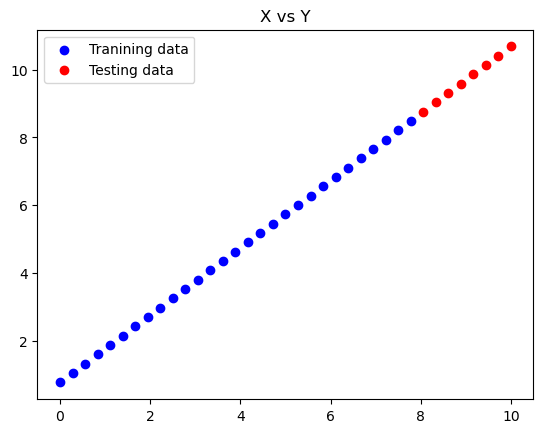

In [39]:
plot_data(X_train,y_train,X_test,y_test)

In [35]:
lr_model = LinearRegression()
lr_model.fit(X_train.reshape(-1,1),y_train)
predictions = lr_model.predict(X_test.reshape(-1,1))

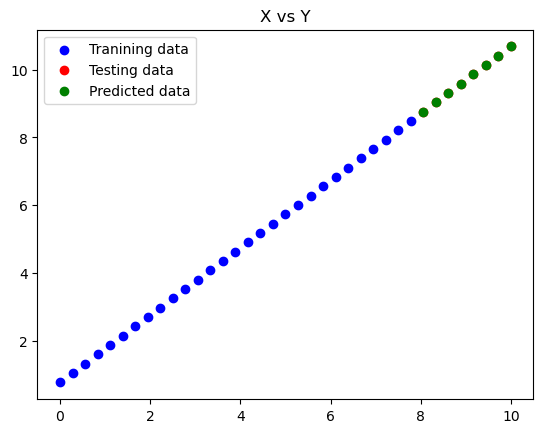

In [40]:
plot_data(predictions=predictions)

In [37]:
from sklearn.metrics import r2_score
print(r2_score(y_true=y_test,y_pred=predictions))

1.0


In [ ]:
from ydata_profiling import ProfileReport 
profile= ProfileReport(df)
profile.to_file("eda.html")

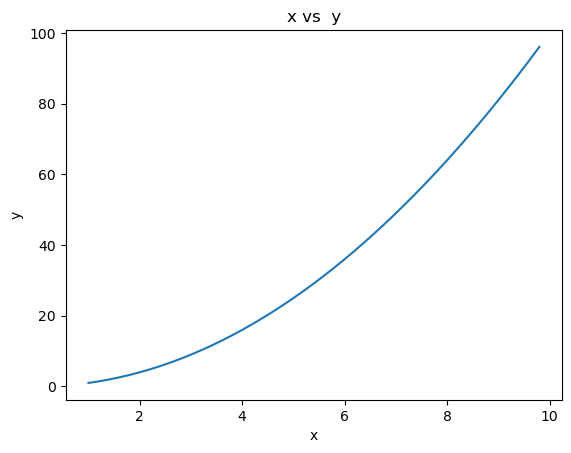

In [1]:
import matplotlib.pyplot as plt 
import numpy as np 

x = np.arange(1,10,0.2)
y = np.square(x)

plt.plot(x,y)
plt.title('x vs  y')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [ ]:
# bar chart is used to compare the categorical data , easy to read 

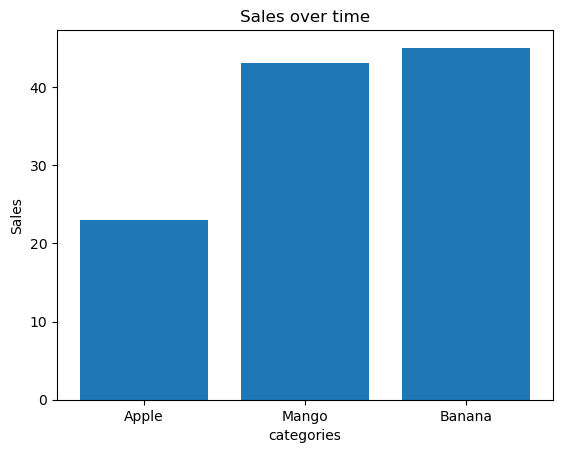

In [2]:
import matplotlib.pyplot as plt 

categories = ['Apple','Mango','Banana']
values = [23,43,45]

plt.bar(categories,values)
plt.title("Sales over time")
plt.xlabel('categories')
plt.ylabel('Sales')
plt.show()

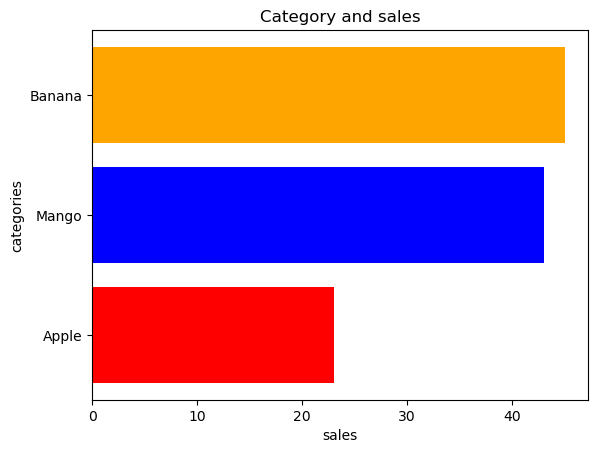

In [3]:
# bar chart horizontal 
import matplotlib.pyplot as plt 
categories = ['Apple','Mango','Banana']
values = [23,43,45]
colors = ['red','blue','orange']

plt.barh(categories,values,color=colors)
plt.title('Category and sales')
plt.xlabel('sales')
plt.ylabel('categories')
plt.show()

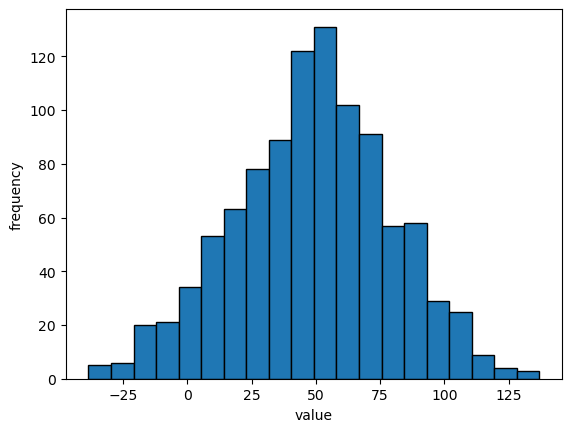

In [9]:
# histogram is used to show data distribuion of numerical values by distributing them into bins, gives distribution of curve skew and outliesr 

import matplotlib.pyplot as plt 
import numpy as np 

x = np.random.normal(loc=50 , scale=30 , size=1000)
plt.hist(x,bins=20,edgecolor='black')
plt.xlabel('value')
plt.ylabel('frequency')
plt.show()

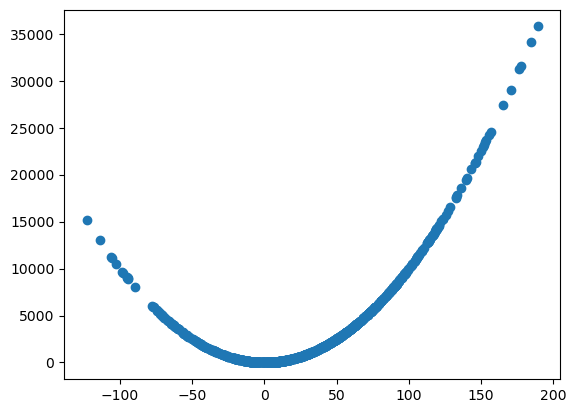

In [8]:
#scatter plots 
import numpy as np
import matplotlib.pyplot as plt 
x = np.random.normal(loc=30,scale=50,size=1000)
y = np.square(x)

plt.scatter(x,y)
plt.show()

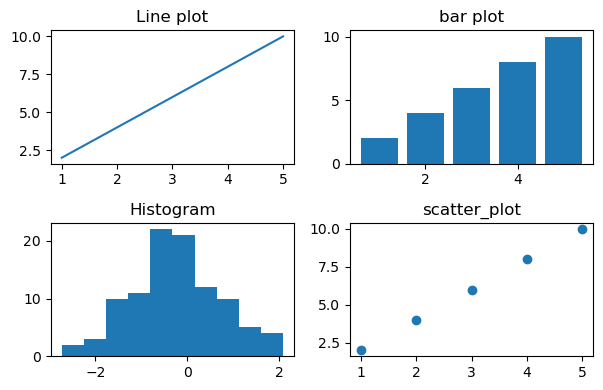

In [20]:
# sub plots 

import matplotlib.pyplot as plt 
import numpy as np 

x = np.arange(1,6)
y = x*2

data = np.random.randn(100)
fig,axes = plt.subplots(2,2,figsize=(6,4))
axes[0,0].plot(x,y)
axes[0,0].set_title("Line plot")

axes[0,1].bar(x,y)
axes[0,1].set_title("bar plot")

axes[1,0].hist(data)
axes[1,0].set_title("Histogram")

axes[1,1].scatter(x,y)
axes[1,1].set_title("scatter_plot")

plt.tight_layout()

<Axes: >

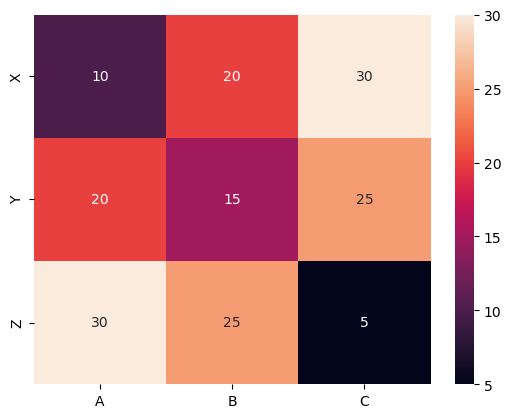

In [23]:
import seaborn as sns 
import pandas as pd
import matplotlib.pyplot as plt 

data = pd.DataFrame(
    [[10,20,30],
    [20,15,25],
    [30,25,5]],
    columns=["A","B","C"],
    index=["X","Y","Z"]
)
sns.heatmap(data,annot=True)


In [25]:
import plotly.express as px 
import pandas as pd 

df = px.data.iris()

fig = px.scatter(df,x='sepal_length',y='sepal_width')
fig.show()

In [27]:
fig = px.bar(df,x='species',y='sepal_length')
fig.show()

In [29]:
fig = px.bar(df , x='species' , y = 'sepal_length')
fig.show()

In [30]:
fig = px.histogram(df,x='sepal_length')
fig.show()

In [ ]:
print("hello")

In [40]:
import numpy as np 
import pandas as pd
data = {
    'StudentID':     ['S01','S02','S03','S04','S05','S06'],
    'Subject':       ['Math','Science','Math','English','Science','English'],
    'Score':         [82, np.nan, 75, np.nan, 91, np.nan],
    'Grade':         ['B','A','C','B','A','C'],
    'AttendancePct': [90, 85, np.nan, 78, 92, 70],
    'StudyHours':    [5, 6, 4, np.nan, 7, 3],
}
df = pd.DataFrame(data)
print(df)


  StudentID  Subject  Score Grade  AttendancePct  StudyHours
0       S01     Math   82.0     B           90.0         5.0
1       S02  Science    NaN     A           85.0         6.0
2       S03     Math   75.0     C            NaN         4.0
3       S04  English    NaN     B           78.0         NaN
4       S05  Science   91.0     A           92.0         7.0
5       S06  English    NaN     C           70.0         3.0


In [41]:
pivot_table = pd.pivot_table(
    df,
    index='Subject',
    values='Score',
    aggfunc='mean'
)
print(pivot_table)

         Score
Subject       
Math      78.5
Science   91.0


In [42]:
df['Score'] = df['Score'].fillna(df['Score'].median())
df['AttendancePct'] = df['AttendancePct'].fillna(df['AttendancePct'].median())
df['StudyHours'] = df['StudyHours'].fillna(df['StudyHours'].median())

In [45]:
df_copy = df.copy()
df_copy

,StudentID,Subject,Score,Grade,AttendancePct,StudyHours
0,S01,Math,82.0,B,90.0,5.0
1,S02,Science,82.0,A,85.0,6.0
2,S03,Math,75.0,C,85.0,4.0
3,S04,English,82.0,B,78.0,5.0
4,S05,Science,91.0,A,92.0,7.0
5,S06,English,82.0,C,70.0,3.0


In [35]:
from sklearn.preprocessing import MinMaxScaler,LabelEncoder
import numpy as np 

def cleaning_pipeline(df):
    for col in df.select_dtypes(include=np.number).columns:
        df[col] = df[col].fillna(df[col].median())
    
    scaler = MinMaxScaler()
    toscale_cols = ['Score','StudyHours']
    df[toscale_cols] = scaler.fit_transform(df[toscale_cols])
    
    cols = ['Subject','Grade']
    for col in cols: 
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col]) 
    
    return df    

In [36]:
df

,StudentID,Subject,Score,Grade,AttendancePct,StudyHours
0,S01,1,0.4375,1,90.0,0.50
1,S02,2,0.4375,0,85.0,0.75
2,S03,1,0.0000,2,85.0,0.25
3,S04,0,0.4375,1,78.0,0.50
4,S05,2,1.0000,0,92.0,1.00
5,S06,0,0.4375,2,70.0,0.00


In [20]:
cleaned_df = cleaning_pipeline(df)
cleaned_df

,StudentID,Subject,Score,Grade,AttendancePct,StudyHours
0,S01,1,0.4375,1,90.0,0.50
1,S02,2,0.4375,0,85.0,0.75
2,S03,1,0.0000,2,85.0,0.25
3,S04,0,0.4375,1,78.0,0.50
4,S05,2,1.0000,0,92.0,1.00
5,S06,0,0.4375,2,70.0,0.00


In [22]:
skewness = df['Score'].skew()
kurtosis = df['Score'].kurt()

if abs(skewness) < 0.5:
    print("Roughly symmetric ")
elif skewness > 0 : 
    print("right tailed")
else:
    print("negative skew")

if kurtosis > 0: 
    print("heavy tails")
elif kurtosis < 0: 
    print("light tails ")
else: 
    print("normal less tails ")

right tailed
heavy tails


In [23]:
df

,StudentID,Subject,Score,Grade,AttendancePct,StudyHours
0,S01,1,0.4375,1,90.0,0.50
1,S02,2,0.4375,0,85.0,0.75
2,S03,1,0.0000,2,85.0,0.25
3,S04,0,0.4375,1,78.0,0.50
4,S05,2,1.0000,0,92.0,1.00
5,S06,0,0.4375,2,70.0,0.00


C:\Users\Sandesh Guragain\AppData\Local\Temp\ipykernel_12392\2552761054.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(score_by_subjects,labels=subjects)


Text(0.5, 1.0, 'Boxplot')

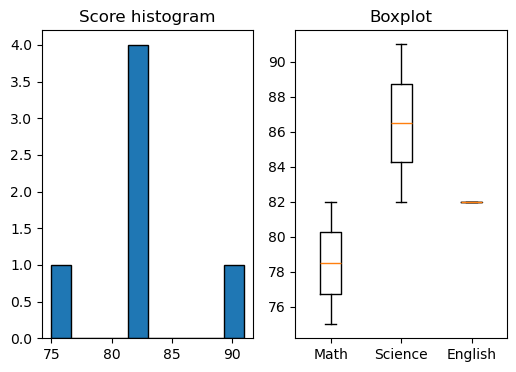

In [60]:
import matplotlib.pyplot as plt 
fig,axes  = plt.subplots(1,2,figsize=(6,4))

axes[0].hist(df_copy['Score'],edgecolor='black')
axes[0].set_title('Score histogram')

subjects = df_copy['Subject'].unique()

score_by_subjects =[df_copy[df_copy['Subject'] == s]['Score'].values for s in subjects]
axes[1].boxplot(score_by_subjects,labels=subjects)
axes[1].set_title('Boxplot')

In [58]:
subjects = df_copy['Subject'].unique()

score_by_subjects =[df_copy[df_copy['Subject'] == s]['Score'].values for s in subjects]
print(score_by_subjects)

[array([82., 75.]), array([82., 91.]), array([82., 82.])]


In [61]:
import pandas as pd
import numpy as np
import plotly.express as px

data = {
    'Subject':  ['Math','Science','Math','English','Science','English'],
    'Score':    [82, np.nan, 75, np.nan, 91, np.nan],
    'AttendancePct': [90, 85, np.nan, 78, 92, 70],
    'StudyHours': [5, 6, 4, np.nan, 7, 3],
}
df = pd.DataFrame(data)
df['Score']         = df['Score'].fillna(df['Score'].median())
df['AttendancePct'] = df['AttendancePct'].fillna(df['AttendancePct'].median())
df['StudyHours']    = df['StudyHours'].fillna(df['StudyHours'].median())

fig = px.scatter_3d(
    df,
    x='StudyHours',
    y='AttendancePct',
    z='Score',
    color='Subject',
    title='3D Scatter: StudyHours vs AttendancePct vs Score',
    labels={'StudyHours': 'Study Hours', 'AttendancePct': 'Attendance %', 'Score': 'Score'},
)
fig.show()


In [8]:
import pandas as pd 
import numpy as np 
import plotly.express as px 

data = {
    'Subject':  ['Math','Science','Math','English','Science','English'],
    'Score':    [82, np.nan, 75, np.nan, 91, np.nan],
    'AttendancePct': [90, 85, np.nan, 78, 92, 70],
    'StudyHours': [5, 6, 4, np.nan, 7, 3],
}
df = pd.DataFrame(data)
df['Score']         = df['Score'].fillna(df['Score'].median())
df['AttendancePct'] = df['AttendancePct'].fillna(df['AttendancePct'].median())
df['StudyHours']    = df['StudyHours'].fillna(df['StudyHours'].median())

df


,Subject,Score,AttendancePct,StudyHours
0,Math,82.0,90.0,5.0
1,Science,82.0,85.0,6.0
2,Math,75.0,85.0,4.0
3,English,82.0,78.0,5.0
4,Science,91.0,92.0,7.0
5,English,82.0,70.0,3.0


In [ ]:
fig = px.scatter_3d(
    df,
    x='StudyHours',
    y='AttendancePct',
    z='Score',
    color='Subject',
    title='3D scatter: StudyHours vs ASttendacnePct vs Score',

)
fig.show()

In [69]:
data = {
    'Subject':      ['Math','Science','Math','English','Science','English'],
    'Score':        [82, np.nan, 75, np.nan, 91, np.nan],
    'AttendancePct':[90, 85, np.nan, 78, 92, 70],
    'StudyHours':   [5, 6, 4, np.nan, 7, 3],
}
df = pd.DataFrame(data)
df['Score']         = df['Score'].fillna(df['Score'].median())
df['AttendancePct'] = df['AttendancePct'].fillna(df['AttendancePct'].median())
df['StudyHours']    = df['StudyHours'].fillna(df['StudyHours'].median())

# Compute descriptive statistics
cols = ['Score', 'AttendancePct', 'StudyHours']
summary = df[cols].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
print(summary)
# Write to Excel with two sheets using xlsxwriter engine
with pd.ExcelWriter("student_report.xlsx", engine='xlsxwriter') as writer:
    summary.to_excel(writer, sheet_name='Summary Statistics')
    df.to_excel(writer, sheet_name='Raw Data', index=False)

print("Excel report saved as student_report.xlsx")


        Score  AttendancePct  StudyHours
mean    82.33          83.33        5.00
median  82.00          85.00        5.00
std      5.09           8.14        1.41
min     75.00          70.00        3.00
max     91.00          92.00        7.00
Excel report saved as student_report.xlsx


In [9]:
data = {
    'OrderID':      ['O01','O02','O03','O04','O05','O06'],
    'Category':     ['Electronics','Clothing','Electronics','Clothing','Books','Books'],
    'Price':        [15000, np.nan, 22000, 1800, 450, np.nan],
    'Quantity':     [2, 5, 1, np.nan, 8, 3],
    'Rating':       [4.5, 3.8, np.nan, 4.1, 4.7, 3.9],
    'DeliveryDays': [3, 5, 2, np.nan, 4, 6],
}
df = pd.DataFrame(data)
df

,OrderID,Category,Price,Quantity,Rating,DeliveryDays
0,O01,Electronics,15000.0,2.0,4.5,3.0
1,O02,Clothing,NaN,5.0,3.8,5.0
2,O03,Electronics,22000.0,1.0,NaN,2.0
3,O04,Clothing,1800.0,NaN,4.1,NaN
4,O05,Books,450.0,8.0,4.7,4.0
5,O06,Books,NaN,3.0,3.9,6.0


In [10]:
df.to_csv('practise1.csv',index=False)

In [11]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   OrderID       6 non-null      object 
 1   Category      6 non-null      object 
 2   Price         4 non-null      float64
 3   Quantity      5 non-null      float64
 4   Rating        5 non-null      float64
 5   DeliveryDays  5 non-null      float64
dtypes: float64(4), object(2)
memory usage: 416.0+ bytes


In [12]:
df['Price'] = df['Price'].fillna(df['Price'].median())
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())
df['Rating'] = df['Rating'].fillna(df['Rating'].median())
df['DeliveryDays'] = df['DeliveryDays'].fillna(df['DeliveryDays'].median())
df['OrderID'] = df['OrderID'].str.replace('O','')
df_copy = df.copy()
df_copy

,OrderID,Category,Price,Quantity,Rating,DeliveryDays
0,01,Electronics,15000.0,2.0,4.5,3.0
1,02,Clothing,8400.0,5.0,3.8,5.0
2,03,Electronics,22000.0,1.0,4.1,2.0
3,04,Clothing,1800.0,3.0,4.1,4.0
4,05,Books,450.0,8.0,4.7,4.0
5,06,Books,8400.0,3.0,3.9,6.0


In [13]:
pivot_table = pd.pivot_table(
    df,
    index='Category',
    values='Price',
    aggfunc='mean'
)
pivot_table

,Price
Category,
Books,4425.0
Clothing,5100.0
Electronics,18500.0


In [14]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
def data_cleaning_pipeline(file_path):
    
    df = pd.read_csv(file_path)
    
    for col in df.select_dtypes(include=np.number).columns:
        df[col] = df[col].fillna(df[col].median())
    
    scaler = StandardScaler()
    col1 = ['Price','Quantity','Rating']
    col2 =['Category']
    df['OrderID'] = df['OrderID'].str.replace('O','')
    df['OrderID'] = df['OrderID'].astype('int')
    df[col1] = scaler.fit_transform(df[col1])
    df = pd.get_dummies(df,columns=col2,drop_first=True).astype(int)
    return df

cleaned_df = data_cleaning_pipeline('practise1.csv')
cleaned_df

,OrderID,Price,Quantity,Rating,DeliveryDays,Category_Clothing,Category_Electronics
0,1,0,0,0,3,0,1
1,2,0,0,-1,5,1,0
2,3,1,-1,0,2,0,1
3,4,-1,0,0,4,1,0
4,5,-1,1,1,4,0,0
5,6,0,0,0,6,0,0


In [15]:
df_copy

,OrderID,Category,Price,Quantity,Rating,DeliveryDays
0,01,Electronics,15000.0,2.0,4.5,3.0
1,02,Clothing,8400.0,5.0,3.8,5.0
2,03,Electronics,22000.0,1.0,4.1,2.0
3,04,Clothing,1800.0,3.0,4.1,4.0
4,05,Books,450.0,8.0,4.7,4.0
5,06,Books,8400.0,3.0,3.9,6.0


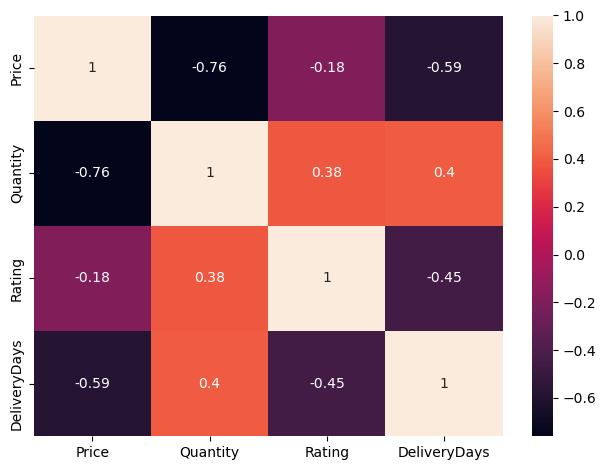

In [16]:
import seaborn as sns
columns = ['Price','Quantity','Rating','DeliveryDays']
df = df_copy[columns]
corr = df.corr(method = 'pearson')
sns.heatmap(corr,annot=True)
plt.tight_layout()
plt.savefig("correlation_heatmap.png")

In [17]:
import numpy as np 
from scipy import stats 

mean_pop = 5 
size = 40 
x_bar = 5.8 
s = 2.1 

sample = np.random.normal(loc=x_bar,scale=s,size=size)
sample = sample-sample.mean()+x_bar
t_value,p_value = stats.ttest_1samp(sample,popmean=mean_pop)

print(f"Scipty t-stat {t_value:.4f}")
print(f"P value :{p_value:.4f}")

if abs(p_value) < 0.05:
    print("Reject null hypothesis ! ")
else:
    print("Accept null hypothesis")

Scipty t-stat 2.1084
P value :0.0415
Reject null hypothesis ! 


Text(0.5, 1.0, 'Price vs Rating')

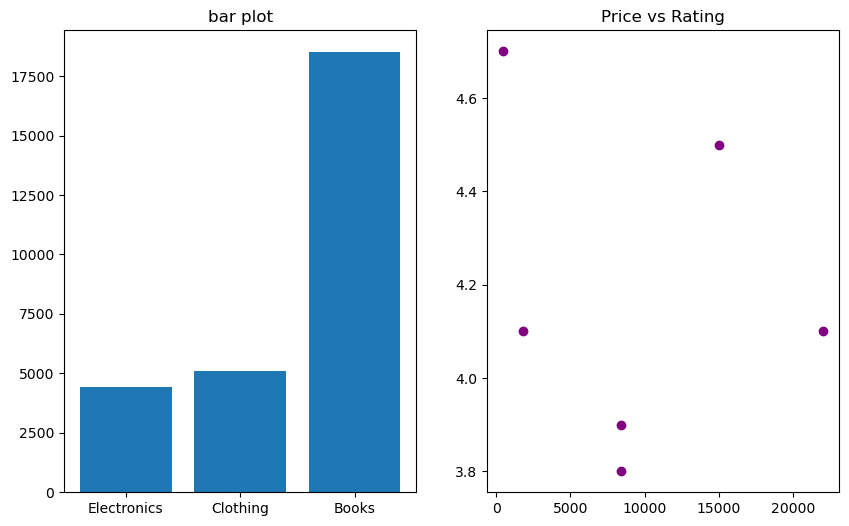

In [27]:
import matplotlib.pyplot as plt 

fig,axes = plt.subplots(1,2,figsize = (10,6))

category = df_copy['Category'].unique()

avg_price = df_copy.groupby('Category')['Price'].mean()
axes[0].bar(category,avg_price)
axes[0].set_title("bar plot")

axes[1].scatter(df_copy['Price'],df['Rating'],color='purple')
axes[1].set_title("Price vs Rating")

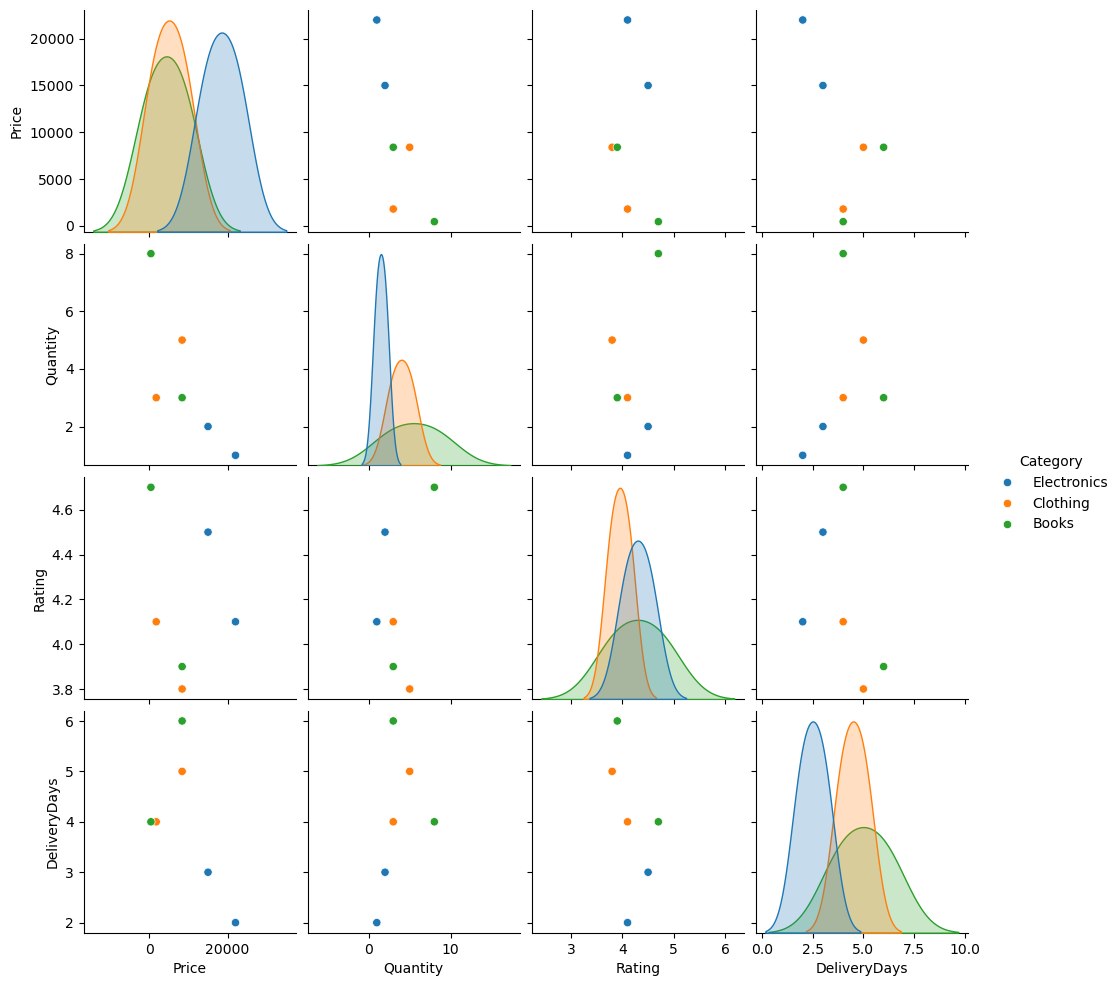

In [31]:
import seaborn as sns 

sns.pairplot(df_copy[['Price','Quantity','Rating','DeliveryDays','Category']],hue='Category')
